# Closed-Loop Refinement

* **Owner:** Pramodya Dewmi
* **Module:** CCS4310 – Deep Learning
* **Project:** Explainable-Fashion-Design-AI

This notebook converts validated model explanations into controlled design-refinement instructions. It does not modify every feature; only a whitelist of mutable design attributes is eligible for change. The score comparison is reported as a predicted/model-aligned score change, not as guaranteed commercial sales improvement.

Workflow:
- initial design and initial score
- identify the weakest negative factors
- generate structured refinement instructions
- apply only the whitelisted design attributes
- re-score with the same model
- compare scores and save the comparison artifact
- include a time-aware helper demonstration only when newer market features are supplied

In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def find_repo_root():
    candidates = [Path.cwd().resolve()]
    candidates.extend(Path.cwd().resolve().parents)
    for p in candidates:
        if (p / 'src').is_dir() and (p / 'data').is_dir() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Repository root not found.')

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES = ROOT / 'outputs' / 'figures'
for d in [METRICS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

from src.explainability.closed_loop import re_evaluate_closer_to_launch, run_closed_loop
from src.explainability.refinement import MUTABLE_DESIGN_ATTRIBUTES
from src.explainability.shap_explainer import explain_row, global_feature_importance

print('Repository root:', ROOT)
print('Allowed design attributes for refinement:', MUTABLE_DESIGN_ATTRIBUTES)

Repository root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI
Allowed design attributes for refinement: ['color', 'fabric', 'category']


In [2]:
MODEL_CONFIG_PAIRS = [
    ('demand', ROOT / 'models' / 'demand' / 'best_demand_model.joblib', ROOT / 'models' / 'demand' / 'demand_model_config.json'),
    ('preference', ROOT / 'models' / 'preference' / 'best_customer_preference_model.joblib', ROOT / 'models' / 'preference' / 'customer_preference_model_config.json'),
    ('preference_dev', ROOT / 'models' / 'preference' / 'best_customer_preference_model_dev.joblib', ROOT / 'models' / 'preference' / 'customer_preference_model_config_dev.json'),
]
selected_pair = next(
    ((kind, model_path, config_path) for kind, model_path, config_path in MODEL_CONFIG_PAIRS if model_path.is_file() and config_path.is_file()),
    None,
)
if selected_pair is None:
    MODEL_KIND = None
    MODEL_PATH = None
    CONFIG_PATH = None
else:
    MODEL_KIND, MODEL_PATH, CONFIG_PATH = selected_pair

if MODEL_PATH is None or CONFIG_PATH is None:
    print('No trained model/config pair was found; this notebook will skip refinement execution until the pipeline is available.')
    MODEL_AVAILABLE = False
else:
    pipeline = joblib.load(MODEL_PATH)
    config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    selected_model = str(config.get('selected_model', '')).strip().lower()
    heuristic_preference_winners = {
        'category preference',
        'global popularity',
        'recent popularity',
    }
    if MODEL_KIND.startswith('preference') and (
        selected_model in heuristic_preference_winners or not hasattr(pipeline, 'named_steps')
    ):
        print('Preference SHAP is unavailable because the selected preference winner is a heuristic baseline.')
        MODEL_AVAILABLE = False
    elif not hasattr(pipeline, 'named_steps'):
        raise TypeError('The saved artifact is not a fitted sklearn Pipeline with prep/model steps; closed-loop refinement requires the trained pipeline.')
    else:
        MODEL_AVAILABLE = True
        run_type = config.get("run_type", "unknown")
        artifact_suffix = "_dev" if run_type != "full" else ""
        required_columns = list(config.get('feature_columns', []))
        categorical_features = list(config.get('categorical_features', []))
        validation_path = INTERIM / 'visuelle_demand_validation.csv'
        if validation_path.exists():
            validation_df = pd.read_csv(validation_path, parse_dates=['time'])
            missing = [col for col in required_columns if col not in validation_df.columns]
            if missing:
                raise ValueError(f'Validation data missing required features: {missing}')
            sample = validation_df.sample(n=min(200, len(validation_df)), random_state=42).reset_index(drop=True)
            X_refine = sample[required_columns]
            print('Validation rows ready for closed-loop refinement:', len(X_refine))
        else:
            print('Validation data not found at', validation_path, '; skipping closed-loop refinement.')
            X_refine = pd.DataFrame()

Validation rows ready for closed-loop refinement: 200


## Refine a single design using the validated SHAP explanation

Initial score: 2.971
Updated score: 3.0775
Score difference: 0.1064
Improvement flag (model-aligned score only): True
Refinement instructions:
- use black instead of yellow for the color


,original_score,refined_score,score_delta,improved,n_suggestions,prompt_hints,run_type
0,2.971027,3.077473,0.106446,True,1,use black instead of yellow for the color,full


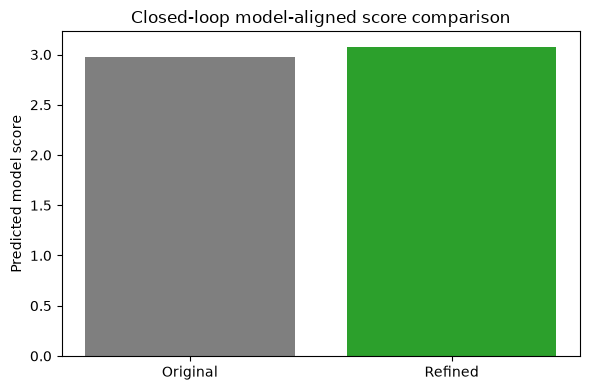

In [3]:
if MODEL_AVAILABLE and not X_refine.empty:
    row_index = 0
    importance_table = global_feature_importance(pipeline, X_refine)
    result = run_closed_loop(
        pipeline,
        X_refine,
        categorical_features=categorical_features,
        row_index=row_index,
        importance_table=importance_table,
        top_n_weak_factors=3,
        mutable_attributes=set(MUTABLE_DESIGN_ATTRIBUTES),
    )
    print('Initial score:', round(result.original_score, 4))
    print('Updated score:', round(result.refined_score, 4))
    print('Score difference:', round(result.score_delta, 4))
    print('Improvement flag (model-aligned score only):', result.improved)
    print('Refinement instructions:')
    for hint in result.prompt_hints:
        print('-', hint)

    comparison = pd.DataFrame([result.as_summary_row()])
    comparison['run_type'] = run_type
    comparison.to_csv(METRICS / f'dewmi_closed_loop_comparison{artifact_suffix}.csv', index=False)
    display(comparison)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Original', 'Refined'], [result.original_score, result.refined_score], color=['#7f7f7f', '#2ca02c'])
    ax.set_ylabel('Predicted model score')
    ax.set_title('Closed-loop model-aligned score comparison')
    fig.tight_layout()
    fig.savefig(FIGURES / f'dewmi_closed_loop_score_comparison{artifact_suffix}.png', dpi=150)
    plt.show()
else:
    print('Skipping closed-loop refinement because the saved model or validation data is unavailable.')

## Time-aware re-evaluation helper

This helper is for later use when newer prepared market rows are available closer to launch. It is intentionally labeled as a helper demonstration unless genuine updated market features are supplied.

In [4]:
if MODEL_AVAILABLE and not X_refine.empty:
    demo_row = X_refine.iloc[[0]].copy()
    output = re_evaluate_closer_to_launch(
        demo_row,
        pipeline,
        required_columns=list(config.get('feature_columns', [])),
        label='Time-aware re-evaluation helper demonstration',
    )
    print(output['label'])
    print('Re-evaluated prediction on the demonstration row:', output['predictions'][0])
    print('This is a demonstration only. No real future-market update was inferred from the same old row.')
else:
    print('Skipping time-aware helper demonstration because the model or validation data is unavailable.')

Time-aware re-evaluation helper demonstration
Re-evaluated prediction on the demonstration row: 2.9710267
This is a demonstration only. No real future-market update was inferred from the same old row.
